Numerical Data Analysis & Outliers

In [26]:
import  pandas as pd

In [27]:
df = pd.read_csv('/Users/mohanrajsubramaniam/PycharmProjects/python_learning/Pandas/datafiles/userData.csv')
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Purpose
0,35,Male,Skilled,Own,Moderate,Little,3500,Car
1,42,Female,Highly Skilled,Rent,Rich,Moderate,12000,Business
2,29,Male,Unskilled & Non-resident,Free,Little,Little,1800,Education
3,51,Female,Skilled,Own,Quite Rich,Rich,8500,Furniture/Equipment
4,38,Male,Highly Skilled,Rent,Moderate,Moderate,6200,Radio/TV


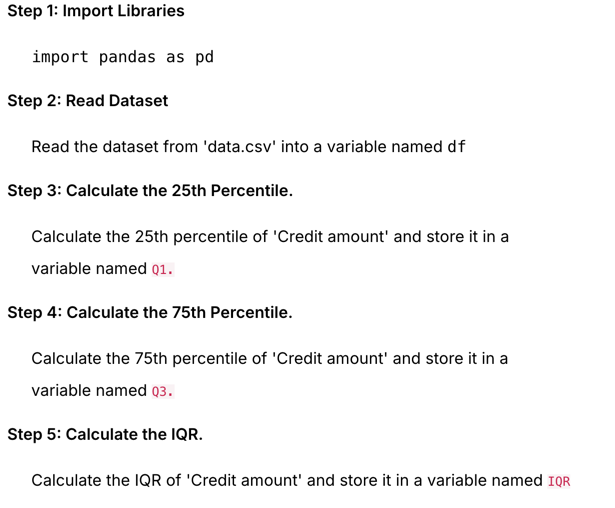

How to calcualte the Q1 (25%) and Q3(75%) values ?

In [28]:
credit_amount_Q1 = df['Credit amount'].quantile(q=0.25)  #Note rename to Q1 to credit amount to add more conditions
credit_amount_Q3 = df['Credit amount'].quantile(q=0.75)
print("Q1: ", credit_amount_Q1)
print("Q3: ", credit_amount_Q3)

Q1:  2825.0
Q3:  11125.0


How to calculate the IQR value ?

Step 5: Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

In [29]:
IQR = credit_amount_Q3 - credit_amount_Q1
print(IQR)

8300.0


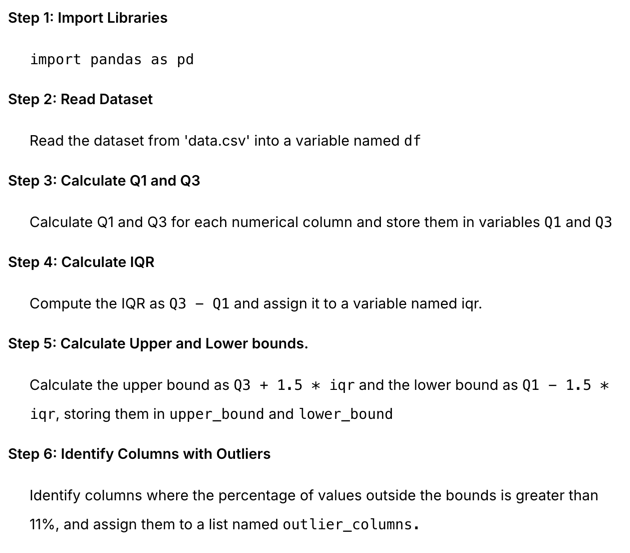

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               10 non-null     int64 
 1   Sex               10 non-null     object
 2   Job               10 non-null     object
 3   Housing           10 non-null     object
 4   Saving accounts   10 non-null     object
 5   Checking account  10 non-null     object
 6   Credit amount     10 non-null     int64 
 7   Purpose           10 non-null     object
dtypes: int64(2), object(6)
memory usage: 772.0+ bytes


In [33]:
list_of_numerical_columns = []
for column in df.columns:
    if df[column].dtype == 'object':
       print(column)
    else:
       list_of_numerical_columns.append(column)
print('list of numerical columns: ', list_of_numerical_columns)

Sex
Job
Housing
Saving accounts
Checking account
Purpose
list of numerical columns:  ['Age', 'Credit amount']


In [34]:
df = pd.read_csv("/Users/mohanrajsubramaniam/PycharmProjects/python_learning/Pandas/datafiles/numerical_data_analysis.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Revenue          10 non-null     int64  
 1   Cost             10 non-null     int64  
 2   Profit Margin    10 non-null     float64
 3   Customer Growth  10 non-null     float64
 4   Market Share     10 non-null     float64
 5   Ad Spend         10 non-null     int64  
dtypes: float64(3), int64(3)
memory usage: 612.0 bytes


In [37]:
Q1 = df.quantile(.25)
Q3 = df.quantile(.75)
iqr = Q3 - Q1
print(Q1)
print(Q3)
print(iqr)


Revenue            99000.000
Cost               67500.000
Profit Margin         32.595
Customer Growth        4.825
Market Share          10.275
Ad Spend           12125.000
Name: 0.25, dtype: float64
Revenue            128250.000
Cost                84000.000
Profit Margin          34.060
Customer Growth         5.625
Market Share           12.950
Ad Spend            15875.000
Name: 0.75, dtype: float64
Revenue            29250.000
Cost               16500.000
Profit Margin          1.465
Customer Growth        0.800
Market Share           2.675
Ad Spend            3750.000
dtype: float64


Calculate Upper and Lower bound

In [38]:
upper_bound = Q3 + 1.5 * iqr
lower_bound = Q1 - 1.5 * iqr
print(upper_bound)
print(lower_bound)

Revenue            172125.0000
Cost               108750.0000
Profit Margin          36.2575
Customer Growth         6.8250
Market Share           16.9625
Ad Spend            21500.0000
dtype: float64
Revenue            55125.0000
Cost               42750.0000
Profit Margin         30.3975
Customer Growth        3.6250
Market Share           6.2625
Ad Spend            6500.0000
dtype: float64


In [40]:
#Identify columns with >11% outliers
outlier_columns = []
for column in df.select_dtypes(include='number').columns:
    outliers = (df[column] < lower_bound[column]) | (df[column] > upper_bound[column])
    outlier_ratio = outliers.mean()
    if outlier_ratio > 0.11:
        outlier_columns.append(column)
print("Columns with >11% outliers:", outlier_columns)


Columns with >11% outliers: []


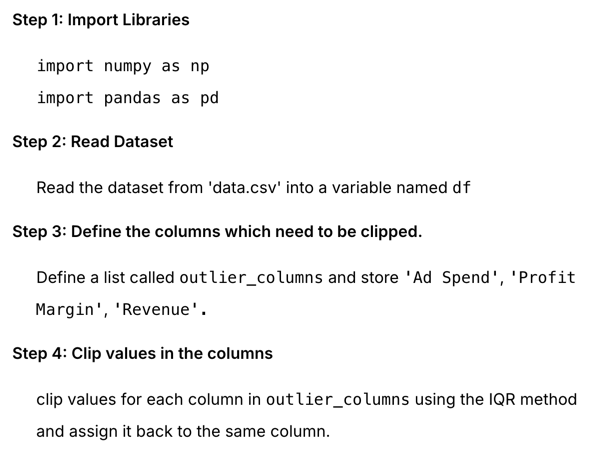

In [42]:
outlier_columns = ['Ad Spend','Profit Margin','Revenue']
for column in outlier_columns:
    print(column)
    Q1 = df[column].quantile(.25)
    Q3 = df[column].quantile(.75)
    IQR = Q3- Q1
    print(Q1)
    print(Q3)
    print(IQR)
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    print(upper_bound)
    print(lower_bound)
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

df.head()

Ad Spend
12125.0
15875.0
3750.0
21500.0
6500.0
Profit Margin
32.595
34.06
1.4650000000000034
36.25750000000001
30.397499999999994
Revenue
99000.0
128250.0
29250.0
172125.0
55125.0


,Revenue,Cost,Profit Margin,Customer Growth,Market Share,Ad Spend
0,120000,80000,33.3300,5.2,12.5,15000
1,95000,67000,30.3975,4.8,10.2,12000
2,150000,100000,33.3300,6.1,14.8,18000
3,110000,75000,31.8200,5.0,11.7,14000
4,98000,64000,34.6900,4.5,9.9,11000


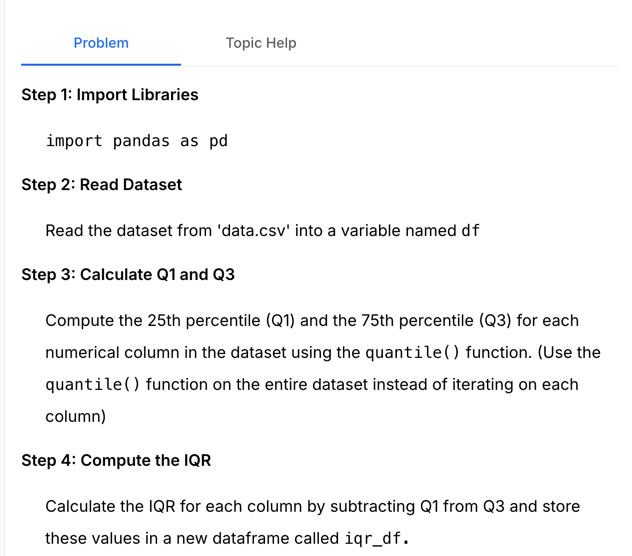

In [47]:
# Step 3: Calculate Q1 and Q3 for all numeric columns
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
# Step 4: Compute IQR and store in a new DataFrame
iqr_df = pd.Series(IQR)

# Optional: display result
print("Interquartile Range (IQR) for each column:")
print(iqr_df)


Interquartile Range (IQR) for each column:
Revenue            29250.000
Cost               16500.000
Profit Margin          1.465
Customer Growth        0.800
Market Share           2.675
Ad Spend            3750.000
dtype: float64
